In [14]:
import numpy as np
import cv2
import os
import math
from numba import cuda
import matplotlib.pyplot as plt

print("CUDA Available:", cuda.is_available())


CUDA Available: True


In [1]:
import os
import cv2
import numpy as np

IMG_SIZE = 28

def load_data(path):
    images = []
    labels = []

    # 1. Safety check to ensure the folder actually exists on your laptop
    if not os.path.exists(path):
        print(f"❌ Error: The folder '{path}' was not found in this directory.")
        return np.array([]), np.array([])

    # Loop through the two categories
    for label, folder in enumerate(["mask", "unmask"]):
        folder_path = os.path.join(path, folder)
        
        if not os.path.exists(folder_path):
            print(f"⚠️ Warning: The subfolder '{folder}' is missing.")
            continue

        print(f"Loading images from '{folder}'...")
        
        for file in os.listdir(folder_path):
            img_path = os.path.join(folder_path, file)
            
            # Read image in Grayscale
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            # Skip corrupted or unreadable files
            if img is None:
                continue

            # Resize the image to 28x28
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            
            # OPTIMIZATION: Keep it as a raw, lightweight uint8 array for now
            images.append(img)
            labels.append(label)

    print("Vectorizing and normalizing data...")
    # OPTIMIZATION: Convert to NumPy and do the float division ONCE on the entire block
    X = np.array(images, dtype=np.float32) / 255.0
    
    # Labels don't need to be floats, they are just 0 or 1
    y = np.array(labels, dtype=np.int32) 

    return X, y

# --- EXECUTION ---
# Use the local folder name instead of Colab's "/content/dataset"
local_dataset_path = "processed_dataset"

X, y = load_data(local_dataset_path)

if len(X) > 0:
    print("\n--- Final Dataset Info ---")
    print(f"Total Images: {len(X)}")
    print(f"Shape of X: {X.shape}")
    print(f"Shape of y: {y.shape}")

Loading images from 'mask'...
Loading images from 'unmask'...
Vectorizing and normalizing data...

--- Final Dataset Info ---
Total Images: 6
Shape of X: (6, 28, 28)
Shape of y: (6,)


In [2]:
from numba import cuda
import math

# ---------------- 1. Convolution 2D ----------------
@cuda.jit
def conv2d(input_img, filters, output):
    # Grid: (Output_X, Output_Y, Num_Filters)
    x, y, f = cuda.grid(3)
    
    # Since input is 28x28 and kernel is 3x3 (no padding), output is 26x26
    if x < 26 and y < 26 and f < filters.shape[0]:
        s = 0.0
        # 3x3 sliding window
        for i in range(3):
            for j in range(3):
                # filters shape: (Num_Filters, 3, 3)
                s += input_img[x+i, y+j] * filters[f, i, j]
        
        output[x, y, f] = s


# ---------------- 2. ReLU Activation ----------------
@cuda.jit
def relu(data):
    # Grid: (X, Y, Num_Filters)
    x, y, f = cuda.grid(3)
    
    if x < data.shape[0] and y < data.shape[1] and f < data.shape[2]:
        # Direct memory access instead of .flat
        if data[x, y, f] < 0.0:
            data[x, y, f] = 0.0


# ---------------- 3. MaxPooling 2x2 ----------------
@cuda.jit
def maxpool(input_img, output):
    # Grid: (Output_X, Output_Y, Num_Filters)
    x, y, f = cuda.grid(3)
    
    # Output size is 13x13 (half of 26x26)
    if x < 13 and y < 13 and f < input_img.shape[2]:
        in_x = x * 2
        in_y = y * 2

        max_val = -999999.0 # Very small initial value

        for i in range(2):
            for j in range(2):
                val = input_img[in_x+i, in_y+j, f]
                if val > max_val:
                    max_val = val

        output[x, y, f] = max_val


# ---------------- 4. Fully Connected + Sigmoid ----------------
@cuda.jit
def fully_connected_sigmoid(pooled_features, weights, bias, output):
    # Grid: 1 Thread (Since we only need 1 output probability)
    if cuda.grid(1) == 0:
        s = bias[0]
        idx = 0
        
        # pooled_features shape: (13, 13, 8)
        # We manually flatten the 3D array into a 1D multiplication
        for f in range(8):
            for x in range(13):
                for y in range(13):
                    s += pooled_features[x, y, f] * weights[idx]
                    idx += 1
        
        # Sigmoid Activation formula: 1 / (1 + e^-s)
        # Cap 's' to prevent math domain errors in C++
        if s < -70.0:
            output[0] = 0.0
        elif s > 70.0:
            output[0] = 1.0
        else:
            output[0] = 1.0 / (1.0 + math.exp(-s))

In [4]:
kernel = np.random.randn(3,3).astype(np.float32)

conv_out_size = IMG_SIZE - 2
pool_size = conv_out_size // 2
fc_input_size = pool_size * pool_size

fc_weights = np.random.randn(2, fc_input_size).astype(np.float32)
fc_bias = np.zeros(2, dtype=np.float32)


In [10]:
print("Initializing Neural Network Weights...")

# 1. Convolutional Filters
# We need 8 filters, each 3x3 in size. 
# (Since the input is a 1-channel grayscale image, we don't need a 4th dimension for RGB)
filters_weights = np.random.uniform(-0.1, 0.1, (8, 3, 3)).astype(np.float32)

# 2. Dense Layer Weights
# After a 28x28 image goes through a 3x3 Conv (no padding) it becomes 26x26.
# After 2x2 MaxPool, it halves to 13x13.
# 13 * 13 spatial dimensions * 8 filters = 1352 flattened features.
dense_weights = np.random.uniform(-0.1, 0.1, (1352,)).astype(np.float32)

# 3. Dense Layer Bias
# We are using a single Sigmoid output, so we only need 1 bias value.
dense_bias = np.random.uniform(-0.1, 0.1, (1,)).astype(np.float32)

Initializing Neural Network Weights...


In [11]:
print("Moving weights to VRAM...")
d_filters = cuda.to_device(filters_weights) # e.g., shape (8, 3, 3)
d_dense_w = cuda.to_device(dense_weights)   # e.g., shape (1352,)
d_dense_b = cuda.to_device(dense_bias)      # e.g., shape (1,)

# ---------------------------------------------------------
# OPTIMIZATION 2: Pre-allocate Memory ONCE
# ---------------------------------------------------------
# We create blank canvases on the GPU to hold intermediate math.
# We will just overwrite these numbers for each new image.
d_input = cuda.device_array((28, 28), dtype=np.float32)
d_conv  = cuda.device_array((26, 26, 8), dtype=np.float32) # 8 filters
d_pool  = cuda.device_array((13, 13, 8), dtype=np.float32) # Shrunk by MaxPool
d_final_prob = cuda.device_array((1,), dtype=np.float32)   # Just 1 Sigmoid output

# Pre-calculate Grid Blocks (Static sizes)
threads3d = (8, 8, 8)
blocks_conv = (math.ceil(26/8), math.ceil(26/8), math.ceil(8/8))
blocks_pool = (math.ceil(13/8), math.ceil(13/8), math.ceil(8/8))

print("Starting Inference Loop...")

# For inference/testing, we only need 1 Epoch.
correct = 0
total_images = len(X)

for i in range(total_images):
    img = X[i]       # Shape: (28, 28)
    label = y[i]     # 1 (Mask) or 0 (No Mask)

    # OPTIMIZATION 3: Copy only the current image to the pre-allocated spot
    # Note: If your dataset is small enough, you could actually move the entire 
    # array `X` to the GPU at once, but this is the standard streaming approach.
    d_input.copy_to_device(img)

    # ----------- 1. Conv2D -----------
    # Launching: conv2d[blocks, threads](input, filters, output)
    conv2d[blocks_conv, threads3d](d_input, d_filters, d_conv)

    # ----------- 2. ReLU -----------
    relu[blocks_conv, threads3d](d_conv)

    # ----------- 3. MaxPool -----------
    maxpool[blocks_pool, threads3d](d_conv, d_pool)

    # ----------- 4. Dense + Sigmoid -----------
    # OPTIMIZATION 4: No D2H CPU transfer! The kernel reads the 3D array 
    # and flattens it mathematically using loops.
    fully_connected_sigmoid[1, 1](d_pool, d_dense_w, d_dense_b, d_final_prob)

    # ----------- 5. Fetch Result -----------
    # This is the ONLY data we pull back from the GPU inside the loop
    probability = d_final_prob.copy_to_host()[0]
    
    # Sigmoid interpretation (Binary Classification)
    prediction = 1 if probability > 0.5 else 0

    if prediction == label:
        correct += 1

    # Optional: Print progress every 100 images
    if (i + 1) % 100 == 0:
        print(f"Processed {i+1}/{total_images}...")

accuracy = (correct / total_images) * 100
print(f"Final Accuracy: {accuracy:.2f}%")

Moving weights to VRAM...
Starting Inference Loop...


c:\Users\dil\AppData\Local\Programs\Python\Python313\Lib\site-packages\numba_cuda\numba\cuda\dispatcher.py:690: NumbaPerformanceWarning: Grid size 16 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
c:\Users\dil\AppData\Local\Programs\Python\Python313\Lib\site-packages\numba_cuda\numba\cuda\dispatcher.py:690: NumbaPerformanceWarning: Grid size 16 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
c:\Users\dil\AppData\Local\Programs\Python\Python313\Lib\site-packages\numba_cuda\numba\cuda\dispatcher.py:690: NumbaPerformanceWarning: Grid size 4 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
c:\Users\dil\AppData\Local\Programs\Python\Python313\Lib\site-packages\numba_cuda\numba\cuda\dispatcher.py:690: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn

Final Accuracy: 50.00%


In [12]:
def predict_image(img):

    # ----------- Conv -----------
    d_input = cuda.to_device(img)
    d_kernel = cuda.to_device(kernel)

    conv_out = np.zeros((IMG_SIZE-2, IMG_SIZE-2), dtype=np.float32)
    d_conv = cuda.to_device(conv_out)

    conv2d[blocks2d, threads2d](d_input, d_kernel, d_conv)

    # ----------- ReLU -----------
    relu[256,256](d_conv)

    # ----------- Pool -----------
    pool_out = np.zeros((pool_size, pool_size), dtype=np.float32)
    d_pool = cuda.to_device(pool_out)

    maxpool[blocks2d, threads2d](d_conv, d_pool)

    flat = d_pool.copy_to_host().flatten()
    d_flat = cuda.to_device(flat)

    # ----------- FC -----------
    d_weights = cuda.to_device(fc_weights)
    d_bias = cuda.to_device(fc_bias)

    fc_out = np.zeros(2, dtype=np.float32)
    d_fc_out = cuda.to_device(fc_out)

    fully_connected[1,2](d_flat, d_weights, d_bias, d_fc_out)

    # ----------- Softmax -----------
    soft_out = np.zeros(2, dtype=np.float32)
    d_soft = cuda.to_device(soft_out)

    softmax[1,1](d_fc_out, d_soft)

    prediction = np.argmax(d_soft.copy_to_host())

    return prediction


c:\Users\dil\AppData\Local\Programs\Python\Python313\Lib\site-packages\numba_cuda\numba\cuda\dispatcher.py:690: NumbaPerformanceWarning: Grid size 16 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
c:\Users\dil\AppData\Local\Programs\Python\Python313\Lib\site-packages\numba_cuda\numba\cuda\dispatcher.py:690: NumbaPerformanceWarning: Grid size 16 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
c:\Users\dil\AppData\Local\Programs\Python\Python313\Lib\site-packages\numba_cuda\numba\cuda\dispatcher.py:690: NumbaPerformanceWarning: Grid size 4 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
c:\Users\dil\AppData\Local\Programs\Python\Python313\Lib\site-packages\numba_cuda\numba\cuda\dispatcher.py:690: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn

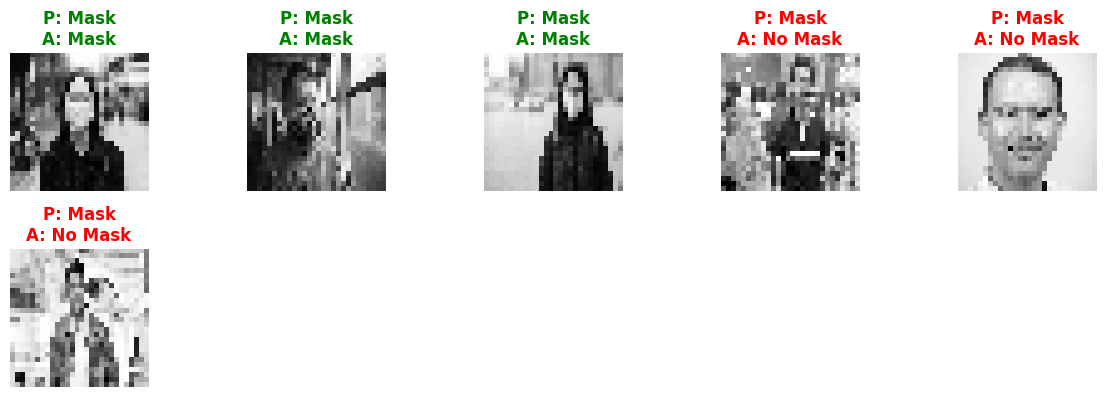

In [19]:
# ==========================================
# 1. THE KERNELS (Strictly 3D for 8 filters)
# ==========================================
@cuda.jit
def conv2d(input_img, filters, output):
    x, y, f = cuda.grid(3)
    if x < 26 and y < 26 and f < filters.shape[0]:
        s = 0.0
        for i in range(3):
            for j in range(3):
                s += input_img[x+i, y+j] * filters[f, i, j]
        output[x, y, f] = s

@cuda.jit
def relu(data):
    x, y, f = cuda.grid(3)
    if x < data.shape[0] and y < data.shape[1] and f < data.shape[2]:
        if data[x, y, f] < 0.0:
            data[x, y, f] = 0.0

@cuda.jit
def maxpool(input_img, output):
    x, y, f = cuda.grid(3)
    if x < 13 and y < 13 and f < input_img.shape[2]:
        in_x = x * 2
        in_y = y * 2
        max_val = -999999.0
        for i in range(2):
            for j in range(2):
                val = input_img[in_x+i, in_y+j, f]
                if val > max_val:
                    max_val = val
        output[x, y, f] = max_val

@cuda.jit
def fully_connected_sigmoid(pooled_features, weights, bias, output):
    if cuda.grid(1) == 0:
        s = bias[0]
        idx = 0
        for f in range(8):
            for x in range(13):
                for y in range(13):
                    s += pooled_features[x, y, f] * weights[idx]
                    idx += 1
        
        if s < -70.0: output[0] = 0.0
        elif s > 70.0: output[0] = 1.0
        else: output[0] = 1.0 / (1.0 + math.exp(-s))

# ==========================================
# 2. INITIALIZE WEIGHTS & MEMORY (Run Once)
# ==========================================
# Generate dummy weights
filters_weights = np.random.uniform(-0.1, 0.1, (8, 3, 3)).astype(np.float32)
dense_weights = np.random.uniform(-0.1, 0.1, (1352,)).astype(np.float32)
dense_bias = np.random.uniform(-0.1, 0.1, (1,)).astype(np.float32)

# Pre-allocate GPU memory
d_input = cuda.device_array((28, 28), dtype=np.float32)
d_conv  = cuda.device_array((26, 26, 8), dtype=np.float32) 
d_pool  = cuda.device_array((13, 13, 8), dtype=np.float32) 
d_final_prob = cuda.device_array((1,), dtype=np.float32)

# Move weights to GPU
d_filters = cuda.to_device(filters_weights) 
d_dense_w = cuda.to_device(dense_weights)   
d_dense_b = cuda.to_device(dense_bias)      

# Define 3D Grid sizes
threads3d = (8, 8, 8)
blocks_conv = (math.ceil(26/8), math.ceil(26/8), math.ceil(8/8))
blocks_pool = (math.ceil(13/8), math.ceil(13/8), math.ceil(8/8))

# ==========================================
# 3. THE PREDICTION FUNCTION
# ==========================================
def predict_image(img):
    # Ensure float32 to prevent Numba typing errors
    img_f32 = img.astype(np.float32)
    
    # Copy to pre-allocated device array
    d_input.copy_to_device(img_f32)

    # Run the CUDA pipeline
    conv2d[blocks_conv, threads3d](d_input, d_filters, d_conv)
    relu[blocks_conv, threads3d](d_conv)
    maxpool[blocks_pool, threads3d](d_conv, d_pool)
    fully_connected_sigmoid[1, 1](d_pool, d_dense_w, d_dense_b, d_final_prob)

    # Fetch result
    probability = d_final_prob.copy_to_host()[0]
    return 1 if probability > 0.5 else 0

# ==========================================
# 4. THE VISUALIZATION LOOP
# ==========================================
class_names = ["Mask", "No Mask"]

plt.figure(figsize=(12, 8))

# Limit to 20 images to fit the 4x5 subplot grid without crashing Matplotlib
num_images_to_plot = min(len(X), 20) 

for i in range(num_images_to_plot):
    pred = predict_image(X[i])
    actual = y[i]

    plt.subplot(4, 5, i+1)
    plt.imshow(X[i], cmap='gray')
    plt.axis("off")

    color = "green" if pred == actual else "red"
    plt.title(f"P: {class_names[pred]}\nA: {class_names[actual]}", color=color, fontweight="bold")

plt.tight_layout()
plt.show()

Initializing Architecture and VRAM...


c:\Users\dil\AppData\Local\Programs\Python\Python313\Lib\site-packages\numba_cuda\numba\cuda\dispatcher.py:690: NumbaPerformanceWarning: Grid size 16 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
c:\Users\dil\AppData\Local\Programs\Python\Python313\Lib\site-packages\numba_cuda\numba\cuda\dispatcher.py:690: NumbaPerformanceWarning: Grid size 16 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
c:\Users\dil\AppData\Local\Programs\Python\Python313\Lib\site-packages\numba_cuda\numba\cuda\dispatcher.py:690: NumbaPerformanceWarning: Grid size 4 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
c:\Users\dil\AppData\Local\Programs\Python\Python313\Lib\site-packages\numba_cuda\numba\cuda\dispatcher.py:690: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn

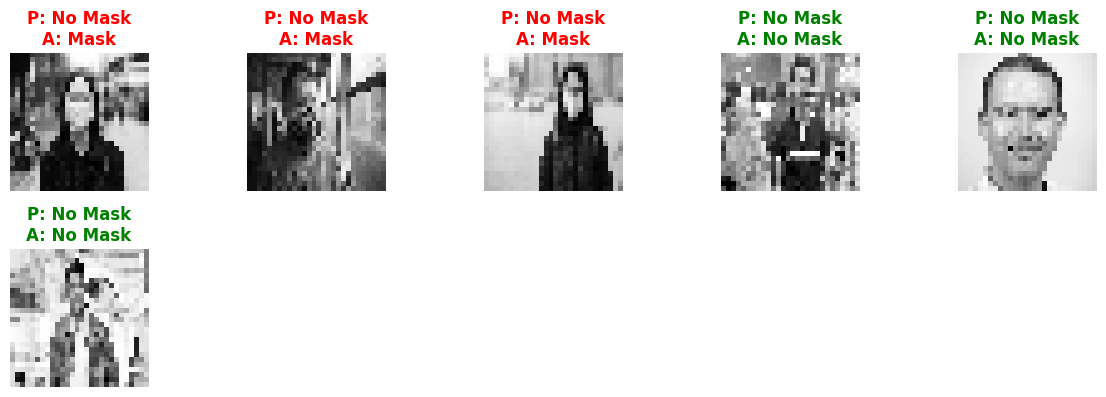

In [18]:
import os
import cv2
import numpy as np
import math
import matplotlib.pyplot as plt
from numba import cuda

# ==========================================
# 1. DATASET LOADER
# ==========================================
def load_data(path, img_size=28):
    images, labels = [], []
    
    if not os.path.exists(path):
        print(f"❌ Error: The folder '{path}' was not found.")
        return np.array([]), np.array([])

    for label, folder in enumerate(["mask", "unmask"]):
        folder_path = os.path.join(path, folder)
        if not os.path.exists(folder_path): continue
        
        for file in os.listdir(folder_path):
            img = cv2.imread(os.path.join(folder_path, file), cv2.IMREAD_GRAYSCALE)
            if img is None: continue
            
            img = cv2.resize(img, (img_size, img_size))
            images.append(img)
            labels.append(label)

    # Vectorized normalization (0.0 to 1.0)
    X = np.array(images, dtype=np.float32) / 255.0
    y = np.array(labels, dtype=np.int32) 
    return X, y

# ==========================================
# 2. RAW CUDA KERNELS (3D Architecture)
# ==========================================
@cuda.jit
def conv2d(input_img, filters, output):
    x, y, f = cuda.grid(3)
    # 28x28 input with 3x3 kernel (no padding) = 26x26 output
    if x < 26 and y < 26 and f < filters.shape[0]:
        s = 0.0
        for i in range(3):
            for j in range(3):
                s += input_img[x+i, y+j] * filters[f, i, j]
        output[x, y, f] = s

@cuda.jit
def relu(data):
    x, y, f = cuda.grid(3)
    if x < data.shape[0] and y < data.shape[1] and f < data.shape[2]:
        if data[x, y, f] < 0.0:
            data[x, y, f] = 0.0

@cuda.jit
def maxpool(input_img, output):
    x, y, f = cuda.grid(3)
    # MaxPool cuts 26x26 down to 13x13
    if x < 13 and y < 13 and f < input_img.shape[2]:
        in_x, in_y = x * 2, y * 2
        max_val = -999999.0
        for i in range(2):
            for j in range(2):
                val = input_img[in_x+i, in_y+j, f]
                if val > max_val:
                    max_val = val
        output[x, y, f] = max_val

@cuda.jit
def fully_connected_sigmoid(pooled_features, weights, bias, output):
    # Single thread reduction for the final probability
    if cuda.grid(1) == 0:
        s = bias[0]
        idx = 0
        for f in range(8):
            for x in range(13):
                for y in range(13):
                    s += pooled_features[x, y, f] * weights[idx]
                    idx += 1
        
        # Sigmoid with domain safety limits
        if s < -70.0: output[0] = 0.0
        elif s > 70.0: output[0] = 1.0
        else: output[0] = 1.0 / (1.0 + math.exp(-s))

# ==========================================
# 3. GPU INITIALIZATION & MEMORY ALLOCATION
# ==========================================
print("Initializing Architecture and VRAM...")

# 1. Generate Dummy Weights (Replace with trained weights later)
filters_weights = np.random.uniform(-0.1, 0.1, (8, 3, 3)).astype(np.float32)
dense_weights = np.random.uniform(-0.1, 0.1, (1352,)).astype(np.float32)
dense_bias = np.random.uniform(-0.1, 0.1, (1,)).astype(np.float32)

# 2. Move Weights to GPU
d_filters = cuda.to_device(filters_weights) 
d_dense_w = cuda.to_device(dense_weights)   
d_dense_b = cuda.to_device(dense_bias)      

# 3. Pre-allocate intermediate tensors
d_input = cuda.device_array((28, 28), dtype=np.float32)
d_conv  = cuda.device_array((26, 26, 8), dtype=np.float32) 
d_pool  = cuda.device_array((13, 13, 8), dtype=np.float32) 
d_final_prob = cuda.device_array((1,), dtype=np.float32)

# 4. Define Thread Blocks
threads3d = (8, 8, 8)
blocks_conv = (math.ceil(26/8), math.ceil(26/8), math.ceil(8/8))
blocks_pool = (math.ceil(13/8), math.ceil(13/8), math.ceil(8/8))

# ==========================================
# 4. PREDICTION FUNCTION
# ==========================================
def predict_image(img):
    """Runs a single 28x28 grayscale image through the GPU Pipeline."""
    # Ensure float32 to prevent Numba typing errors
    d_input.copy_to_device(img.astype(np.float32))

    # Execute Kernels
    conv2d[blocks_conv, threads3d](d_input, d_filters, d_conv)
    relu[blocks_conv, threads3d](d_conv)
    maxpool[blocks_pool, threads3d](d_conv, d_pool)
    fully_connected_sigmoid[1, 1](d_pool, d_dense_w, d_dense_b, d_final_prob)

    # Fetch Probability
    probability = d_final_prob.copy_to_host()[0]
    return 1 if probability > 0.5 else 0

# ==========================================
# 5. EXECUTION & VISUALIZATION
# ==========================================
if __name__ == "__main__":
    # Load the Data
    X, y = load_data("processed_dataset")
    
    if len(X) > 0:
        class_names = ["Mask", "No Mask"]
        num_images_to_plot = min(len(X), 20) 
        
        plt.figure(figsize=(12, 8))
        
        for i in range(num_images_to_plot):
            pred = predict_image(X[i])
            actual = y[i]

            plt.subplot(4, 5, i+1)
            plt.imshow(X[i], cmap='gray')
            plt.axis("off")

            color = "green" if pred == actual else "red"
            plt.title(f"P: {class_names[pred]}\nA: {class_names[actual]}", color=color, fontweight="bold")

        plt.tight_layout()
        plt.show()